## Emotion Classification with RNNs, LSTMs & GRUs
Classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an Advanced Bidirectional GRU.

## 1. Import Libraries

Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
!pip install datasets

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset # it helps to load data


## 2. Load Dataset
Load the dair-ai/emotion dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [3]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

In [4]:
label_names=emotion_dataset['train'].features['label'].names
label_names


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
df_train=pd.DataFrame({
    'text':train_text,
    'label':[label_names[i] for i in train_label]
})

df_test=pd.DataFrame({
    'text':test_text,
    'label':[label_names[i] for i in test_label]
})

In [6]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [8]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

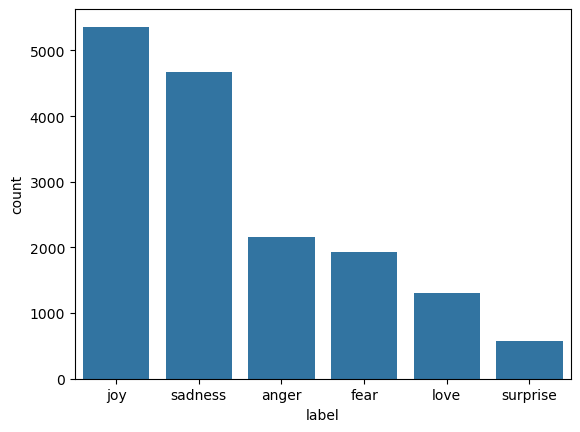

In [9]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [10]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [11]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [12]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000

tokenizer=Tokenizer(num_words=max_words,oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes=len(np.unique(train_labels))
num_classes

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [14]:
from sklearn.utils import class_weight

class_weight = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict=dict(enumerate(class_weight))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

In [16]:
# Model 1 — Simple RNN
# Plain unrolled Recurrent Neural Network

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding,Dense,Dropout,LSTM,GRU

rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax') 
])
rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

D:\Jupyter\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.1631 - loss: 1.8987 - val_accuracy: 0.2170 - val_loss: 1.7763
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1607 - loss: 1.8064 - val_accuracy: 0.2525 - val_loss: 1.7746
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1590 - loss: 1.7807 - val_accuracy: 0.2420 - val_loss: 1.7668
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.1674 - loss: 1.7633 - val_accuracy: 0.1610 - val_loss: 1.7605
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1746 - loss: 1.7581 - val_accuracy: 0.0795 - val_loss: 1.8586
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1751 - loss: 1.7365 - val_accuracy: 0.1500 - val_loss: 1.7966
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1752 - loss: 1.7240 - val_accuracy: 0.1410 - val_loss: 1.8072
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1610 - loss: 1.7605
RNN Loss: 1.76053

In [18]:
# Model 2 — Standard LSTM
# Plain stacked Long Short-Term Memory network.

lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])
lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.1464 - loss: 1.7947 - val_accuracy: 0.3305 - val_loss: 1.7926
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.1426 - loss: 1.7940 - val_accuracy: 0.2880 - val_loss: 1.7828
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1542 - loss: 1.8026 - val_accuracy: 0.0330 - val_loss: 1.8071
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.1262 - loss: 1.7941 - val_accuracy: 0.1375 - val_loss: 1.7846
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.1204 - loss: 1.7936 - val_accuracy: 0.0330 - val_loss: 1.7928
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2880 - loss: 1.7828
LSTM Loss: 1.7828410863876343
LSTM Accuracy: 0.2879999876022339


In [19]:
# Model 3 — Standard GRU
# Plain stacked Gated Recurrent Unit network

gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.1508 - loss: 1.7961 - val_accuracy: 0.2865 - val_loss: 1.8186
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.1617 - loss: 1.7958 - val_accuracy: 0.0365 - val_loss: 1.7890
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1554 - loss: 1.7944 - val_accuracy: 0.0800 - val_loss: 1.8041
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1596 - loss: 1.7918 - val_accuracy: 0.0690 - val_loss: 1.8588
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.1496 - loss: 1.7810 - val_accuracy: 0.0860 - val_loss: 1.7959
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0365 - loss: 1.7890
GRU Loss: 1.7889798879623413
GRU Accuracy: 0.0364999994635582


In [20]:
# Phase 1 Ranking & Selection
# Rank foundational models to pick the best base cell for Phase 2

results_df=pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Test Loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy',ascending=False)
results_df




,Model,Test Loss,Test Accuracy
1,LSTM,1.782841,0.2880
0,RNN,1.760534,0.1610
2,GRU,1.788980,0.0365


## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

In [21]:
# Model 4 — Advanced Stacked Bidirectional GRU
from tensorflow.keras.layers import Bidirectional

BiGRU=Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')
])
BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
BiGRU.summary()

D:\Jupyter\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train & Evaluate Advanced Bidirectional GRU

BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")
    


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 125ms/step - accuracy: 0.5674 - loss: 1.0402 - val_accuracy: 0.8950 - val_loss: 0.3374
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 119ms/step - accuracy: 0.9214 - loss: 0.2236 - val_accuracy: 0.9220 - val_loss: 0.1811
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.9475 - loss: 0.1373 - val_accuracy: 0.9185 - val_loss: 0.2121
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 108ms/step - accuracy: 0.9590 - loss: 0.1079 - val_accuracy: 0.9165 - val_loss: 0.2402
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.9693 - loss: 0.0870 - val_accuracy: 0.9245 - val_loss: 0.2372
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9220 - loss: 0.1811
BiGRU Loss: 0.18108749389648438
BiGRU Accuracy: 0.921999990940094


## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


<Axes: >

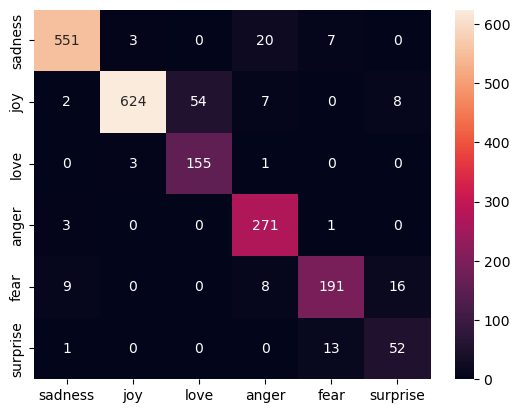

In [31]:
# Final Model Confusion Matrices (Raw Counts & Normalized %)

from sklearn.metrics import confusion_matrix
BiGRU_predictions =np.argmax(BiGRU.predict(padded_test_sequence),axis=1)
sns.heatmap(confusion_matrix(test_label,BiGRU_predictions),annot=True,fmt='d',xticklabels=label_names, yticklabels=label_names)


## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [36]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences,maxlen=50,padding='post',truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [40]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

# Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

# Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)